# People counter using CSRNET (Congestion Scene Recognition Network)

## 1. Importing all dependencies

In [9]:
import tensorflow as tf
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras as krs

from keras.preprocessing.image import load_img, img_to_array
from keras.applications import mobilenet_v2, resnet50, vgg16
from keras.layers import Conv2D, BatchNormalization, Reshape, Conv2DTranspose, Dropout, MaxPooling2D, LayerNormalization
from keras.losses import SparseCategoricalCrossentropy
from keras.optimizers import Adam, SGD
from keras.layers import Rescaling, Normalization
from keras.initializers import RandomNormal

from IPython.display import Image, display
import PIL
from PIL import ImageOps

from tensorflow.data.experimental import AUTOTUNE
from keras.models import Model, Sequential
import scipy.io

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

In [3]:
print(f"Tensorflow version: {tf.__version__}")
print(f"Keras version: {krs.__version__}")

Tensorflow version: 2.21.0
Keras version: 3.13.2


## 2. Downloading the dataset (Data loading)

In [30]:
train_images_path = "../data/part_A/train_data/images/"
train_maps_path = "../data/part_A/train_data/ground-truth/"

train_images = Path("../data/part_A/train_data/images/")
train_maps = Path("../data/part_A/train_data/ground-truth/")

In [28]:
if train_images.exists():
    print("Dataset already exists")

Dataset already exists


## 3. Explorative Data Analysis

## 4. Data cleaning

## 5. Data Preparation (data splitting, encoding, standard, normalizing)

In [4]:
IN_X, IN_Y = 768, 1024
OUT_X, OUT_Y = 96, 128
SUBSAMPLING_FACTOR = IN_X // IN_Y

In [5]:
def gauss_distribution(x, u = 0, sigma = 10):
    return np.expand_dims((1 / (np.sqrt(2 * np.pi * (sigma ** 2)))) * np.exp(-0.5 * (((x - u) / sigma) ** 2)), axis = 0)

In [6]:
def get_density_map_gaussian(im,points,gaussian_radius = 4):
    density_map = np.zeros((OUT_X,OUT_Y))
    w,h = OUT_Y,OUT_X
    num_gt = len(points)

    for point in points:
        point = np.round(point).astype(int)
        point[0], point[1] = min(h - 1, point[1]), min(w - 1, point[0])
        x = np.linspace(-gaussian_radius,gaussian_radius,(gaussian_radius*2)+1)
        gaussian_map = np.multiply(gauss_distribution(x),gauss_distribution(x).T)
        gaussian_map /= np.sum(gaussian_map)

        x_left,x_right,y_up,y_down = 0,gaussian_map.shape[1],0,gaussian_map.shape[0]

        if point[1] < gaussian_radius:
            x_left = gaussian_radius-point[1]
        if point[0] < gaussian_radius:
            y_up = gaussian_radius - point[0]
        if point[1] + gaussian_radius >= w:
            x_right = gaussian_map.shape[1] - (gaussian_radius + point[1] - w) - 1
        if point[0] + gaussian_radius >= h:
            y_down = gaussian_map.shape[0] - (gaussian_radius + point[0] - h) - 1

        density_map[
            max(0,point[0]-gaussian_radius):min(density_map.shape[0],point[0]+gaussian_radius+1),
            max(0,point[1]-gaussian_radius):min(density_map.shape[1],point[1]+gaussian_radius+1),
        ]+=gaussian_map[y_up:y_down,x_left:x_right]
    density_map/=np.sum(density_map/len(points))
    return density_map

In [7]:
print(gauss_distribution(np.linspace(-40, 40, 40 * 2 + 1), sigma = 3))

[[3.31005236e-40 2.66627592e-38 1.92185392e-36 1.23959757e-34
  7.15461245e-33 3.69518827e-31 1.70778063e-29 7.06273085e-28
  2.61371533e-26 8.65543644e-25 2.56486621e-23 6.80119956e-22
  1.61380619e-20 3.42659119e-19 6.51055884e-18 1.10692781e-16
  1.68409036e-15 2.29274913e-14 2.79314024e-13 3.04490680e-12
  2.97030006e-11 2.59281602e-10 2.02529428e-09 1.41562958e-08
  8.85433970e-08 4.95573172e-07 2.48201529e-06 1.11236208e-05
  4.46100753e-05 1.60090217e-04 5.14092999e-04 1.47728280e-03
  3.79866201e-03 8.74062970e-03 1.79969888e-02 3.31590463e-02
  5.46700249e-02 8.06569082e-02 1.06482669e-01 1.25794409e-01
  1.32980760e-01 1.25794409e-01 1.06482669e-01 8.06569082e-02
  5.46700249e-02 3.31590463e-02 1.79969888e-02 8.74062970e-03
  3.79866201e-03 1.47728280e-03 5.14092999e-04 1.60090217e-04
  4.46100753e-05 1.11236208e-05 2.48201529e-06 4.95573172e-07
  8.85433970e-08 1.41562958e-08 2.02529428e-09 2.59281602e-10
  2.97030006e-11 3.04490680e-12 2.79314024e-13 2.29274913e-14
  1.6840

In [32]:
IN = "processed_IMG_1"

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.488232..1.8840895].


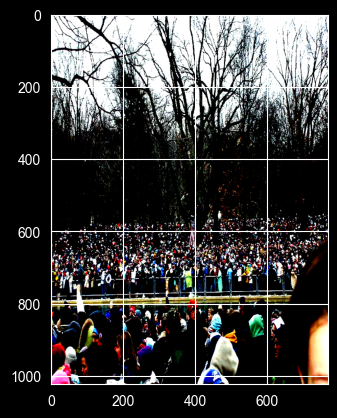

In [34]:
im_array = img_to_array(load_img(train_images_path + IN + '.jpg', target_size = (IN_Y, IN_X)))

im_array /= 255
im_array[:, :, 0] = (im_array[:, :, 0] - np.mean(im_array[:, :, 0])) / np.std(im_array[:, :, 0])
im_array[:, :, 1] = (im_array[:, :, 1] - np.mean(im_array[:, :, 1])) / np.std(im_array[:, :, 1])
im_array[:, :, 2] = (im_array[:, :, 2] - np.mean(im_array[:, :, 2])) / np.std(im_array[:, :, 2])

X = im_array
plt.imshow(X)

In [35]:
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, images, maps, batch_size,SUBSAMPLING_FACTOR=8):

        self.images = images
        self.maps = maps
        self.batch_size = batch_size
        self.train_image_list=os.listdir(images)
        self.SUBSAMPLING_FACTOR=SUBSAMPLING_FACTOR

    def __len__(self):
        return int(np.floor(len(self.train_image_list)/self.batch_size))

    def __getitem__(self, idx):
        x,y = self.__data_generation(idx)
        return x,y

    def __data_generation(self, idx):
        x = []
        y = []

        for j in range(idx*self.batch_size, (idx+1)*self.batch_size):

            im_array=img_to_array(load_img(self.images+os.listdir(self.images)[j],target_size=(IN_X,IN_Y)))
            im_array/=255.
            im_array[:,:,0]=(im_array[:,:,0]-np.mean(im_array[:,:,0]))/np.std(im_array[:,:,0])
            im_array[:,:,1]=(im_array[:,:,1]-np.mean(im_array[:,:,1]))/np.std(im_array[:,:,1])
            im_array[:,:,2]=(im_array[:,:,2]-np.mean(im_array[:,:,2]))/np.std(im_array[:,:,2])
            x.append(im_array)
            mat=scipy.io.loadmat(self.maps+os.listdir(self.maps)[j])
            points=mat['image_info'][0][0][0][0][0]
            points/=self.SUBSAMPLING_FACTOR

            density_map_present=get_density_map_gaussian(im_array,points,sigma=5)
            y.append(density_map_present)

        return tf.convert_to_tensor(x), tf.convert_to_tensor(y)

In [ ]:
train_images='...'
train_maps='...'
val_images='...'
val_maps='...'

LR=1e-4
BATCH_SIZE=1
EPOCH=1000

In [ ]:
train_gen = DataGenerator(images, maps, BATCH_SIZE, INPUT_DIM)
#val_gen = DataGenerator(val_images, val_maps,BATCH_SIZE,INPUT_DIM)

## 6. Model building and evaluating